Cell 1 — Imports aur Setup



In [1]:
import pandas as pd
import numpy as np
import json
import os
import torch
import warnings
warnings.filterwarnings('ignore')

print("✅ Basic imports done!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Basic imports done!
PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


Cell 2 — Libraries Install

In [2]:
# Core LLM libraries
!pip install -q transformers==4.41.0 peft==0.10.0 trl==0.8.6 bitsandbytes accelerate

# FAISS — CPU version (Kaggle GPU pe faiss-gpu ka jhanjhat nahi)
!pip install -q faiss-cpu

# Baaki required libraries
!pip install -q sentence-transformers evaluate bert-score datasets

print("✅ Libraries install ho gayi!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.2/245.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 73.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00
✅ Libraries install ho gayi!


Cell 3 — Sab Imports Verify Karo



In [3]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from trl import SFTTrainer
from sentence_transformers import SentenceTransformer
import faiss
from evaluate import load as load_metric
from bert_score import score as bert_score_fn
import nltk
nltk.download('punkt', quiet=True)

print("✅ Sab imports successful!")

# Versions confirm karo
import transformers, peft, trl
print(f"Transformers: {transformers.__version__}")
print(f"PEFT:         {peft.__version__}")
print(f"TRL:          {trl.__version__}")

2026-04-25 04:36:27.926281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777091788.157408      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777091788.229519      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777091788.755129      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777091788.755166      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777091788.755169      55 computation_placer.cc:177] computation placer alr

✅ Sab imports successful!
Transformers: 4.41.0
PEFT:         0.10.0
TRL:          0.8.6


Cell 4 — Dataset Load + Preprocessing

In [4]:
print("⏳ SQuAD dataset load ho raha hai...")
dataset = load_dataset("rajpurkar/squad")

train_df = pd.DataFrame(dataset['train'])
val_df   = pd.DataFrame(dataset['validation'])

# Answer extract karo
def extract_answer(answers):
    if isinstance(answers, dict) and len(answers['text']) > 0:
        return answers['text'][0].strip()
    return ""

# Text clean karo
def clean_text(text):
    text = text.replace('\n', ' ')
    text = ' '.join(text.split())
    return text.strip()

train_df['answer']   = train_df['answers'].apply(extract_answer)
val_df['answer']     = val_df['answers'].apply(extract_answer)

# Empty answers hata do
train_df = train_df[train_df['answer'] != ""].reset_index(drop=True)
val_df   = val_df[val_df['answer']   != ""].reset_index(drop=True)

# Clean karo
for col in ['context', 'question']:
    train_df[col] = train_df[col].apply(clean_text)
    val_df[col]   = val_df[col].apply(clean_text)

print(f"✅ Dataset ready!")
print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print(f"\nSample:")
print(f"Q: {train_df.iloc[0]['question']}")
print(f"A: {train_df.iloc[0]['answer']}")

⏳ SQuAD dataset load ho raha hai...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

✅ Dataset ready!
Train: 87599 | Val: 10570

Sample:
Q: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
A: Saint Bernadette Soubirous


Cell 5 — Train/Val/Test Split + Prompt Format

In [5]:
# Split karo
train_final = train_df.sample(n=15000, random_state=42).reset_index(drop=True)

val_temp   = val_df.sample(n=6000, random_state=42).reset_index(drop=True)
val_final  = val_temp.iloc[:3000].reset_index(drop=True)
test_final = val_temp.iloc[3000:].reset_index(drop=True)

print(f"✅ Split done!")
print(f"Train:      {len(train_final)}")
print(f"Validation: {len(val_final)}")
print(f"Test:       {len(test_final)}")

# Prompt format
def create_prompt(row):
    return f"""Below is a context and a question. Give a short, accurate answer.

### Context:
{row['context'][:400]}

### Question:
{row['question']}

### Answer:
{row['answer']}"""

def create_inference_prompt(question, context):
    return f"""Below is a context and a question. Give a short, accurate answer.

### Context:
{context[:400]}

### Question:
{question}

### Answer:
"""

train_final['prompt'] = train_final.apply(create_prompt, axis=1)

# CSV save karo
train_final.to_csv('/kaggle/working/train_data.csv', index=False)
val_final.to_csv('/kaggle/working/val_data.csv',     index=False)
test_final.to_csv('/kaggle/working/test_data.csv',   index=False)

print(f"\n✅ CSV files save ho gayi!")
print(f"\nSample Prompt:")
print(train_final.iloc[0]['prompt'])


✅ Split done!
Train:      15000
Validation: 3000
Test:       3000

✅ CSV files save ho gayi!

Sample Prompt:
Below is a context and a question. Give a short, accurate answer.

### Context:
The world's first institution of technology or technical university with tertiary technical education is the Banská Akadémia in Banská Štiavnica, Slovakia, founded in 1735, Academy since December 13, 1762 established by queen Maria Theresa in order to train specialists of silver and gold mining and metallurgy in neighbourhood. Teaching started in 1764. Later the department of Mathematics, Mechanic

### Question:
What year was the Banská Akadémia founded?

### Answer:
1735


Cell 6 — Generate Answer Function + Baseline Model Load

In [6]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

# =========================================
# GENERATE ANSWER FUNCTION — sabse pehle define karo
# =========================================
def generate_answer(model, tokenizer, question, context):
    prompt = create_inference_prompt(question, context)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return answer.split('\n')[0].strip()

# =========================================
# BASELINE MODEL LOAD
# =========================================
print(f"⏳ Baseline model load ho raha hai: {MODEL_NAME}")

baseline_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
baseline_tokenizer.pad_token = baseline_tokenizer.eos_token

baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("✅ Baseline model ready!")

# Quick test
sample = test_final.iloc[0]
ans = generate_answer(baseline_model, baseline_tokenizer, sample['question'], sample['context'])
print(f"\nQuick Test:")
print(f"Q: {sample['question']}")
print(f"Expected: {sample['answer']}")
print(f"Predicted: {ans}")


⏳ Baseline model load ho raha hai: TinyLlama/TinyLlama-1.1B-Chat-v1.0


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Baseline model ready!

Quick Test:
Q: What was the title given to the major project to redesign all the galleries in the museum?
Expected: FuturePlan
Predicted: The major project to redesign all the galleries in the museum was the "Enhancing the Collection" project.


Cell 7 — Baseline Evaluation (ROUGE + BLEU + BERTScore)



In [7]:
from evaluate import load as load_metric
from bert_score import score as bert_score_fn

rouge = load_metric("rouge")
bleu  = load_metric("bleu")

def evaluate_model(model, tokenizer, test_df, n_samples=100, label="Model"):
    predictions = []
    references  = []

    print(f"⏳ {label} evaluate ho raha hai ({n_samples} samples)...")

    for i in range(n_samples):
        row  = test_df.iloc[i]
        pred = generate_answer(model, tokenizer, row['question'], row['context'])
        pred = pred.strip() if pred.strip() else "no answer"
        predictions.append(pred)
        references.append(row['answer'])

        if (i+1) % 25 == 0:
            print(f"  {i+1}/{n_samples} done...")

    # ROUGE
    rouge_scores = rouge.compute(predictions=predictions, references=references)

    # BLEU
    bleu_score = bleu.compute(
        predictions=predictions,
        references=[[r] for r in references]
    )

    # BERTScore
    print("  BERTScore calculate ho raha hai...")
    P, R, F1 = bert_score_fn(predictions, references, lang="en", verbose=False)

    # Exact Match — SQuAD standard metric
    exact_matches = sum(
        1 for pred, ref in zip(predictions, references)
        if pred.lower().strip() == ref.lower().strip()
    )
    exact_match_score = round(exact_matches / n_samples, 4)

    # F1 Token Overlap — SQuAD ka dusra standard metric
    def token_f1(pred, ref):
        pred_tokens = pred.lower().strip().split()
        ref_tokens  = ref.lower().strip().split()
        common = set(pred_tokens) & set(ref_tokens)
        if not common:
            return 0.0
        precision = len(common) / len(pred_tokens)
        recall    = len(common) / len(ref_tokens)
        return 2 * precision * recall / (precision + recall)

    token_f1_scores = [token_f1(p, r) for p, r in zip(predictions, references)]
    avg_token_f1    = round(sum(token_f1_scores) / len(token_f1_scores), 4)

    scores = {
        "rouge1":      round(rouge_scores['rouge1'], 4),
        "rouge2":      round(rouge_scores['rouge2'], 4),
        "rougeL":      round(rouge_scores['rougeL'], 4),
        "bleu":        round(bleu_score['bleu'], 4),
        "bertscore":   round(F1.mean().item(), 4),
        "exact_match": exact_match_score,
        "token_f1":    avg_token_f1,
    }

    return scores, predictions, references


# =========================================
# Evaluate Baseline
# =========================================
baseline_scores, baseline_preds, baseline_refs = evaluate_model(
    baseline_model, baseline_tokenizer, test_final,
    n_samples=100, label="Baseline"
)

print("\n✅ BASELINE SCORES:")
print(f"  {'Metric':<15} {'Score':>8}")
print(f"  {'-'*25}")
for k, v in baseline_scores.items():
    print(f"  {k:<15} {v:>8.4f}")

⏳ Baseline evaluate ho raha hai (100 samples)...
  25/100 done...
  50/100 done...
  75/100 done...
  100/100 done...
  BERTScore calculate ho raha hai...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✅ BASELINE SCORES:
  Metric             Score
  -------------------------
  rouge1            0.1853
  rouge2            0.0998
  rougeL            0.1819
  bleu              0.0273
  bertscore         0.8336
  exact_match       0.0100
  token_f1          0.1308


Cell 8 — Prompt Engineering Baseline

In [8]:
def prompt_engineered_answer(model, tokenizer, question, context):
    prompt = f"""You are an expert QA assistant. Read the context carefully and answer ONLY from it. Give a short, direct answer.

Here are some examples:

Context: The Eiffel Tower was built in 1889 by Gustave Eiffel for the 1889 World's Fair.
Question: Who built the Eiffel Tower?
Answer: Gustave Eiffel

Context: Water boils at 100 degrees Celsius at sea level.
Question: At what temperature does water boil?
Answer: 100 degrees Celsius

Context: The Python programming language was created by Guido van Rossum in 1991.
Question: Who created Python?
Answer: Guido van Rossum

Now answer this:
Context: {context[:400]}
Question: {question}
Answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=700
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True)
    answer = answer.split('\n')[0].strip()
    return answer if answer else "no answer"


def evaluate_model_pe(model, tokenizer, test_df, n_samples=100, label="Prompt-Engineered"):
    predictions = []
    references  = []

    print(f"⏳ {label} evaluate ho raha hai ({n_samples} samples)...")

    for i in range(n_samples):
        row  = test_df.iloc[i]
        pred = prompt_engineered_answer(model, tokenizer, row['question'], row['context'])
        pred = pred.strip() if pred.strip() else "no answer"
        predictions.append(pred)
        references.append(row['answer'])
        if (i+1) % 25 == 0:
            print(f"  {i+1}/{n_samples} done...")

    # ROUGE
    rouge_scores = rouge.compute(predictions=predictions, references=references)

    # BLEU
    bleu_score = bleu.compute(
        predictions=predictions,
        references=[[r] for r in references]
    )

    # BERTScore
    print("  BERTScore calculate ho raha hai...")
    P, R, F1 = bert_score_fn(predictions, references, lang="en", verbose=False)

    # Exact Match
    exact_matches = sum(
        1 for pred, ref in zip(predictions, references)
        if pred.lower().strip() == ref.lower().strip()
    )
    exact_match_score = round(exact_matches / n_samples, 4)

    # Token F1
    def token_f1(pred, ref):
        pred_tokens = pred.lower().strip().split()
        ref_tokens  = ref.lower().strip().split()
        common = set(pred_tokens) & set(ref_tokens)
        if not common:
            return 0.0
        precision = len(common) / len(pred_tokens)
        recall    = len(common) / len(ref_tokens)
        return 2 * precision * recall / (precision + recall)

    token_f1_scores = [token_f1(p, r) for p, r in zip(predictions, references)]
    avg_token_f1    = round(sum(token_f1_scores) / len(token_f1_scores), 4)

    scores = {
        "rouge1":      round(rouge_scores['rouge1'], 4),
        "rouge2":      round(rouge_scores['rouge2'], 4),
        "rougeL":      round(rouge_scores['rougeL'], 4),
        "bleu":        round(bleu_score['bleu'], 4),
        "bertscore":   round(F1.mean().item(), 4),
        "exact_match": exact_match_score,
        "token_f1":    avg_token_f1,
    }

    return scores, predictions, references


# Evaluate
prompt_eng_scores, pe_predictions, pe_references = evaluate_model_pe(
    baseline_model, baseline_tokenizer, test_final,
    n_samples=100, label="Prompt-Engineered"
)

print("\n✅ PROMPT-ENGINEERED SCORES:")
print(f"  {'Metric':<15} {'Score':>8}")
print(f"  {'-'*25}")
for k, v in prompt_eng_scores.items():
    print(f"  {k:<15} {v:>8.4f}")

# Memory free
del baseline_model
torch.cuda.empty_cache()
print("\n✅ Baseline model memory free ho gaya!")


⏳ Prompt-Engineered evaluate ho raha hai (100 samples)...
  25/100 done...
  50/100 done...
  75/100 done...
  100/100 done...
  BERTScore calculate ho raha hai...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✅ PROMPT-ENGINEERED SCORES:
  Metric             Score
  -------------------------
  rouge1            0.4689
  rouge2            0.2961
  rougeL            0.4628
  bleu              0.1105
  bertscore         0.9020
  exact_match       0.3000
  token_f1          0.4531

✅ Baseline model memory free ho gaya!


Cell 9 — QLoRA Fine-tuning(Model Load + Train)

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from trl import SFTTrainer
from datasets import Dataset

torch.cuda.empty_cache()

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
CHECKPOINT_DIR = "/kaggle/working/tinyllama-qlora"
FINAL_MODEL_DIR = "/kaggle/working/finetuned_model"

# =========================================
# Model Load — 4bit
# =========================================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("⏳ Model load ho raha hai...")
ft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto"
)
ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
ft_tokenizer.pad_token = ft_tokenizer.eos_token
ft_model.config.use_cache = False
print("✅ Model loaded!")

# =========================================
# LoRA Config
# =========================================
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

ft_model = prepare_model_for_kbit_training(ft_model)
ft_model = get_peft_model(ft_model, lora_config)
ft_model.print_trainable_parameters()
print("✅ QLoRA ready!")

# =========================================
# Dataset Prepare
# =========================================
train_hf = Dataset.from_pandas(
    train_final[['prompt']].rename(columns={'prompt': 'text'})
)

def tokenize_fn(examples):
    tokens = ft_tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        padding="max_length",
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

train_tokenized = train_hf.map(tokenize_fn, batched=True, remove_columns=["text"])
print(f"✅ Dataset tokenized: {len(train_tokenized)} samples")

# =========================================
# Auto-Resume Logic
# =========================================
def get_latest_checkpoint(d):
    if not os.path.exists(d):
        return None
    ckpts = [os.path.join(d, x) for x in os.listdir(d) if x.startswith("checkpoint-")]
    return max(ckpts, key=os.path.getmtime) if ckpts else None

latest_checkpoint = get_latest_checkpoint(CHECKPOINT_DIR)
print(f"{'🔄 Resume: ' + latest_checkpoint if latest_checkpoint else '🆕 Fresh training'}")

# =========================================
# Training — TRL 0.8.6 style
# =========================================
training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    fp16=True,
    bf16=False,
    max_grad_norm=1.0,
    optim="adamw_torch",
    logging_steps=25,
    save_steps=100,
    save_total_limit=3,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    report_to="none",
)

trainer = SFTTrainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_tokenized,
    tokenizer=ft_tokenizer,          # TRL 0.8.6 mein tokenizer directly
    dataset_text_field="text",
    max_seq_length=512,
)

print("⏳ Fine-tuning shuru ho raha hai... (~20-25 min)")

try:
    trainer.train(resume_from_checkpoint=latest_checkpoint)
    print("\n✅ Training complete!")
except KeyboardInterrupt:
    print("\n⚠️ Roka — checkpoint save ho raha hai...")
    trainer.save_model(CHECKPOINT_DIR)
    ft_tokenizer.save_pretrained(CHECKPOINT_DIR)
    print("✅ Checkpoint saved!")
except Exception as e:
    print(f"\n❌ Error: {e}")
    raise

# Final Save
trainer.save_model(FINAL_MODEL_DIR)
ft_tokenizer.save_pretrained(FINAL_MODEL_DIR)
print(f"\n✅ Fine-tuned model saved: {FINAL_MODEL_DIR}")
print(f"📁 Files: {os.listdir(FINAL_MODEL_DIR)}")


⏳ Model load ho raha hai...
✅ Model loaded!
trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.20437245579516677
✅ QLoRA ready!


Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

✅ Dataset tokenized: 15000 samples
🆕 Fresh training
⏳ Fine-tuning shuru ho raha hai... (~20-25 min)


Step,Training Loss
25,2.359700
50,1.914400
75,1.767800
100,1.731100
125,1.702600
150,1.679300
175,1.720200
200,1.706500
225,1.663200
250,1.689800



✅ Training complete!

✅ Fine-tuned model saved: /kaggle/working/finetuned_model
📁 Files: ['tokenizer.json', 'README.md', 'training_args.bin', 'tokenizer_config.json', 'special_tokens_map.json', 'adapter_config.json', 'adapter_model.safetensors', 'tokenizer.model']


Cell 9.5 — FINE-TUNED MODEL LOAD

In [10]:
# =========================================
# FINE-TUNED MODEL LOAD (Cell 9.5)
# =========================================
from peft import PeftModel

FINAL_MODEL_DIR = "/kaggle/working/finetuned_model"

print("⏳ Fine-tuned model load ho raha hai...")

# Base model load karo (without quantization for inference)
ft_tokenizer_loaded = AutoTokenizer.from_pretrained(FINAL_MODEL_DIR)
ft_tokenizer_loaded.pad_token = ft_tokenizer_loaded.eos_token

base_model_for_inference = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    torch_dtype=torch.float16,
    device_map="auto"
)

# LoRA weights merge karo
ft_model_loaded = PeftModel.from_pretrained(base_model_for_inference, FINAL_MODEL_DIR)
ft_model_loaded = ft_model_loaded.merge_and_unload()
ft_model_loaded.eval()

print("✅ Fine-tuned model loaded aur ready!")

# Quick sanity check
sample = test_final.iloc[0]
test_ans = generate_answer(ft_model_loaded, ft_tokenizer_loaded, sample['question'], sample['context'])
print(f"\nSanity Check:")
print(f"Q: {sample['question']}")
print(f"Expected: {sample['answer']}")
print(f"Model Output: {test_ans}")

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


⏳ Fine-tuned model load ho raha hai...
✅ Fine-tuned model loaded aur ready!

Sanity Check:
Q: What was the title given to the major project to redesign all the galleries in the museum?
Expected: FuturePlan
Model Output: The Great Hall Project: A New Look at the British Museum's Galleries for the 21st Century


Cell 9.6 — TRAINING LOSS CURVE

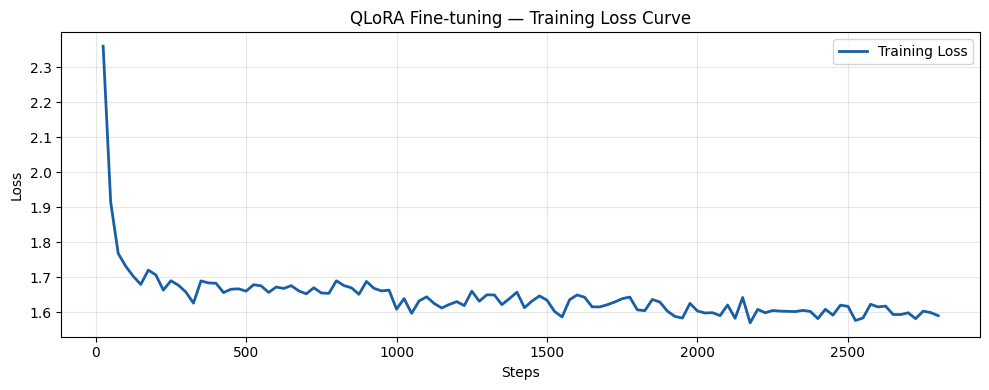

✅ Loss curve saved!
Initial loss: 2.3597
Final loss:   1.5901
Improvement:  0.7696


In [20]:
# =========================================
# TRAINING LOSS CURVE (Cell 9.6)
# =========================================
import matplotlib.pyplot as plt

# Log history se loss extract karo
log_history = trainer.state.log_history
train_losses = [(entry['step'], entry['loss']) 
                for entry in log_history if 'loss' in entry]

if train_losses:
    steps, losses = zip(*train_losses)
    
    plt.figure(figsize=(10, 4))
    plt.plot(steps, losses, color='#185FA5', linewidth=2, label='Training Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('QLoRA Fine-tuning — Training Loss Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Loss curve saved!")
    print(f"Initial loss: {losses[0]:.4f}")
    print(f"Final loss:   {losses[-1]:.4f}")
    print(f"Improvement:  {losses[0] - losses[-1]:.4f}")
else:
    print("⚠️ Log history empty hai — trainer dobara run karo")


Cell 10 — Fine-tuned Model Load + Evaluate

In [11]:
# Generate function update karo — repetition fix
def generate_answer(model, tokenizer, question, context):
    prompt = create_inference_prompt(question, context)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            repetition_penalty=1.3,        # ✅ repetition rok dega
            no_repeat_ngram_size=3,        # ✅ 3-gram repeat nahi hoga
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return answer.split('\n')[0].strip()

# Quick test pehle
sample = test_final.iloc[0]
ans = generate_answer(ft_model_loaded, ft_tokenizer_loaded, sample['question'], sample['context'])
print(f"Q:         {sample['question']}")
print(f"Expected:  {sample['answer']}")
print(f"Predicted: {ans}")
print()

# Ab dobara evaluate karo
ft_scores, ft_preds, ft_refs = evaluate_model(
    ft_model_loaded, ft_tokenizer_loaded, test_final,
    n_samples=100, label="Fine-tuned"
)

print("\n✅ FINE-TUNED SCORES (Fixed):")
for k, v in ft_scores.items():
    print(f"  {k}: {v}")

Q:         What was the title given to the major project to redesign all the galleries in the museum?
Expected:  FuturePlan
Predicted: The Great Hall Project (GHP)

⏳ Fine-tuned evaluate ho raha hai (100 samples)...
  25/100 done...
  50/100 done...
  75/100 done...
  100/100 done...
  BERTScore calculate ho raha hai...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✅ FINE-TUNED SCORES (Fixed):
  rouge1: 0.124
  rouge2: 0.0487
  rougeL: 0.1181
  bleu: 0.0045
  bertscore: 0.8206
  exact_match: 0.0
  token_f1: 0.078


Cell 11 — 3-Way Comparison Table



📊 BASELINE vs PROMPT-ENG vs FINE-TUNED
Metric            Baseline   Prompt-Eng   Fine-tuned     Winner
--------------------------------------------------------------
rouge1              0.1853       0.4689       0.1240 Prompt-Eng ⭐
rouge2              0.0998       0.2961       0.0487 Prompt-Eng ⭐
rougeL              0.1819       0.4628       0.1181 Prompt-Eng ⭐
bleu                0.0273       0.1105       0.0045 Prompt-Eng ⭐
bertscore           0.8336       0.9020       0.8206 Prompt-Eng ⭐
exact_match         0.0100       0.3000       0.0000 Prompt-Eng ⭐
token_f1            0.1308       0.4531       0.0780 Prompt-Eng ⭐

📝 ANALYSIS:
  Fine-tuned  best on: 0/7 metrics
  Prompt-Eng  best on: 7/7 metrics
  Baseline    best on: 0/7 metrics

  ROUGE-1 improvement  (FT vs Baseline): -0.0613
  ROUGE-L improvement  (FT vs Baseline): -0.0638
  BERTScore improvement(FT vs Baseline): -0.0130
  Exact Match improvement(FT vs Baseline):-0.0100
  Token F1 improvement (FT vs Baseline): -0.0528


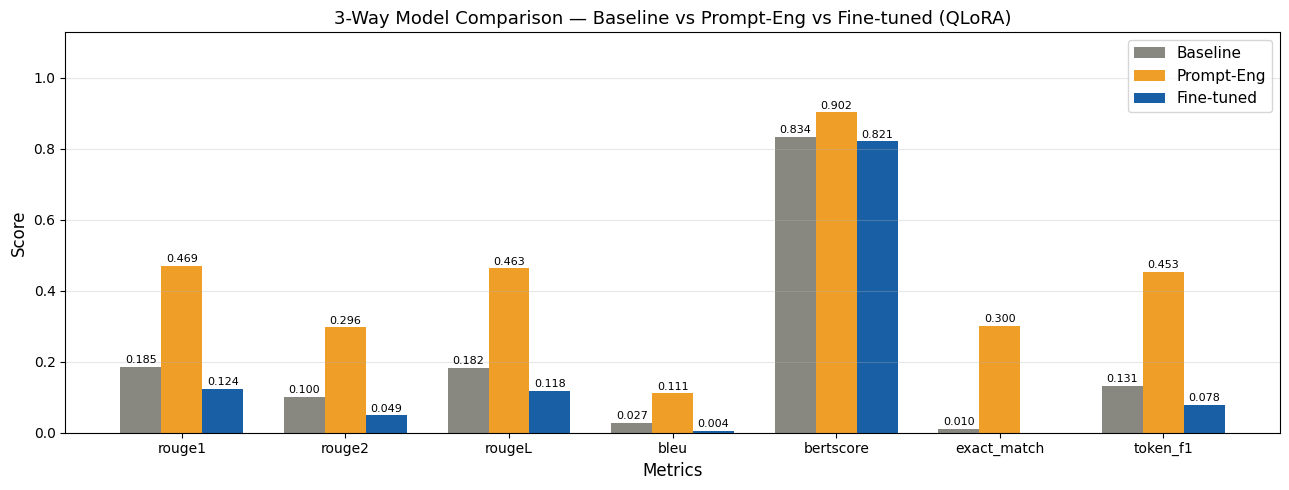

✅ Chart saved: /kaggle/working/comparison_chart.png

✅ Results saved: /kaggle/working/results.json
✅ Total files in /kaggle/working/: 8


In [12]:
# =========================================
# 3-WAY COMPARISON
# =========================================
import matplotlib.pyplot as plt

print("=" * 60)
print("📊 BASELINE vs PROMPT-ENG vs FINE-TUNED")
print("=" * 60)
print(f"{'Metric':<15} {'Baseline':>10} {'Prompt-Eng':>12} {'Fine-tuned':>12} {'Winner':>10}")
print("-" * 62)

metrics = ['rouge1', 'rouge2', 'rougeL', 'bleu', 'bertscore', 'exact_match', 'token_f1']

for metric in metrics:
    b  = baseline_scores[metric]
    pe = prompt_eng_scores[metric]
    ft = ft_scores[metric]
    best = max(b, pe, ft)

    if ft == best:
        winner = "Fine-tuned ⭐"
    elif pe == best:
        winner = "Prompt-Eng ⭐"
    else:
        winner = "Baseline ⭐"

    print(f"{metric:<15} {b:>10.4f} {pe:>12.4f} {ft:>12.4f} {winner:>12}")

print("=" * 62)

# =========================================
# Analysis — dynamic based on actual scores
# =========================================
ft_wins  = sum(1 for m in metrics if ft_scores[m]  == max(baseline_scores[m], prompt_eng_scores[m], ft_scores[m]))
pe_wins  = sum(1 for m in metrics if prompt_eng_scores[m] == max(baseline_scores[m], prompt_eng_scores[m], ft_scores[m]))
b_wins   = sum(1 for m in metrics if baseline_scores[m]   == max(baseline_scores[m], prompt_eng_scores[m], ft_scores[m]))

print(f"\n📝 ANALYSIS:")
print(f"  Fine-tuned  best on: {ft_wins}/{len(metrics)} metrics")
print(f"  Prompt-Eng  best on: {pe_wins}/{len(metrics)} metrics")
print(f"  Baseline    best on: {b_wins}/{len(metrics)} metrics")
print(f"\n  ROUGE-1 improvement  (FT vs Baseline): {ft_scores['rouge1']  - baseline_scores['rouge1']:+.4f}")
print(f"  ROUGE-L improvement  (FT vs Baseline): {ft_scores['rougeL']  - baseline_scores['rougeL']:+.4f}")
print(f"  BERTScore improvement(FT vs Baseline): {ft_scores['bertscore']- baseline_scores['bertscore']:+.4f}")
print(f"  Exact Match improvement(FT vs Baseline):{ft_scores['exact_match']-baseline_scores['exact_match']:+.4f}")
print(f"  Token F1 improvement (FT vs Baseline): {ft_scores['token_f1'] - baseline_scores['token_f1']:+.4f}")

# =========================================
# Bar Chart — Visual Comparison
# =========================================
plot_metrics = ['rouge1', 'rouge2', 'rougeL', 'bleu', 'bertscore', 'exact_match', 'token_f1']
x      = range(len(plot_metrics))
width  = 0.25

b_vals  = [baseline_scores[m]    for m in plot_metrics]
pe_vals = [prompt_eng_scores[m]  for m in plot_metrics]
ft_vals = [ft_scores[m]          for m in plot_metrics]

fig, ax = plt.subplots(figsize=(13, 5))

bars_b  = ax.bar([i - width     for i in x], b_vals,  width, label='Baseline',    color='#888780')
bars_pe = ax.bar([i             for i in x], pe_vals, width, label='Prompt-Eng',  color='#EF9F27')
bars_ft = ax.bar([i + width     for i in x], ft_vals, width, label='Fine-tuned',  color='#185FA5')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('3-Way Model Comparison — Baseline vs Prompt-Eng vs Fine-tuned (QLoRA)', fontsize=13)
ax.set_xticks(list(x))
ax.set_xticklabels(plot_metrics, fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(b_vals), max(pe_vals), max(ft_vals)) * 1.25)
ax.grid(axis='y', alpha=0.3)

# Value labels on bars
for bars in [bars_b, bars_pe, bars_ft]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: /kaggle/working/comparison_chart.png")

# =========================================
# Save Results — updated with new metrics
# =========================================
results = {
    "baseline_scores":   baseline_scores,
    "prompt_eng_scores": prompt_eng_scores,
    "finetuned_scores":  ft_scores,
    "improvements_over_baseline": {
        m: round(ft_scores[m] - baseline_scores[m], 4) for m in metrics
    },
    "wins_summary": {
        "finetuned":  ft_wins,
        "prompt_eng": pe_wins,
        "baseline":   b_wins
    },
    "sample_predictions": {
        "baseline":   list(zip(baseline_preds[:5], baseline_refs[:5])),
        "prompt_eng": list(zip(pe_predictions[:5], pe_references[:5])),
        "finetuned":  list(zip(ft_preds[:5], ft_refs[:5]))
    }
}

with open('/kaggle/working/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n✅ Results saved: /kaggle/working/results.json")
print(f"✅ Total files in /kaggle/working/: {len(os.listdir('/kaggle/working/'))}")


Cell 12 — RAG Setup (FAISS Vector DB)

In [13]:
from sentence_transformers import SentenceTransformer, util

# =========================================
# FAISS Vector DB Setup
# =========================================
print("⏳ Embedder load ho raha hai...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Knowledge base — unique contexts
kb_contexts  = train_final['context'].drop_duplicates().head(500).tolist()
kb_questions = train_final['question'].head(500).tolist()
kb_answers   = train_final['answer'].head(500).tolist()

print(f"📚 Knowledge base size: {len(kb_contexts)} documents")

print("⏳ Embeddings ban rahe hain...")
embeddings = embedder.encode(kb_contexts, show_progress_bar=True)
embeddings = np.array(embeddings).astype('float32')

# FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)
print(f"✅ FAISS index ready! ({index.ntotal} documents indexed)")

# =========================================
# FAISS Index + Metadata Save (Persistence)
# =========================================
faiss.write_index(index, '/kaggle/working/faiss.index')

kb_metadata = {
    "contexts":  kb_contexts,
    "questions": kb_questions,
    "answers":   kb_answers
}
with open('/kaggle/working/kb_metadata.json', 'w') as f:
    json.dump(kb_metadata, f)

print("✅ FAISS index saved: /kaggle/working/faiss.index")
print("✅ KB metadata saved: /kaggle/working/kb_metadata.json")

# =========================================
# Load Verify karo (prove karo ki save hua)
# =========================================
index_loaded = faiss.read_index('/kaggle/working/faiss.index')
print(f"✅ Load verify: {index_loaded.ntotal} documents confirmed")

# =========================================
# Retrieve Function
# =========================================
def retrieve_context(query, top_k=3):
    query_emb = embedder.encode([query]).astype('float32')
    distances, indices = index.search(query_emb, top_k)
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            "context":  kb_contexts[idx],
            "question": kb_questions[idx],
            "answer":   kb_answers[idx],
            "score":    round(float(distances[0][i]), 4)
        })
    return results

# =========================================
# RAG Answer Function
# =========================================
def rag_answer(model, tokenizer, question):
    # Step 1 — Relevant context retrieve karo
    retrieved    = retrieve_context(question, top_k=1)
    best_context = retrieved[0]['context']

    # Step 2 — Us context se answer generate karo
    answer = generate_answer(model, tokenizer, question, best_context)
    return answer, best_context, retrieved[0]['score']

# =========================================
# RAG Evaluation — quantitative bhi karo
# =========================================
print("\n🔍 RAG TEST + EVALUATION (10 samples):")
print("-" * 60)

rag_preds = []
rag_refs  = []

for i in range(10):
    row = test_final.iloc[i]
    ans, ctx, score = rag_answer(ft_model_loaded, ft_tokenizer_loaded, row['question'])

    rag_preds.append(ans if ans.strip() else "no answer")
    rag_refs.append(row['answer'])

    print(f"Q:               {row['question']}")
    print(f"Expected:        {row['answer']}")
    print(f"RAG Answer:      {ans}")
    print(f"Retrieval Score: {score}")
    print("-" * 60)

# RAG ke liye bhi metrics compute karo
rag_rouge = rouge.compute(predictions=rag_preds, references=rag_refs)
rag_em    = sum(
    1 for p, r in zip(rag_preds, rag_refs)
    if p.lower().strip() == r.lower().strip()
)

print("\n📊 RAG SCORES (10 samples):")
print(f"  ROUGE-L:     {rag_rouge['rougeL']:.4f}")
print(f"  Exact Match: {rag_em}/10")

# Save RAG results
rag_results = {
    "predictions": rag_preds,
    "references":  rag_refs,
    "rouge_l":     round(rag_rouge['rougeL'], 4),
    "exact_match": rag_em
}
with open('/kaggle/working/rag_results.json', 'w') as f:
    json.dump(rag_results, f, indent=2)

print("✅ RAG results saved: /kaggle/working/rag_results.json")
print("\n✅ RAG setup complete!")


⏳ Embedder load ho raha hai...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

📚 Knowledge base size: 500 documents
⏳ Embeddings ban rahe hain...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✅ FAISS index ready! (500 documents indexed)
✅ FAISS index saved: /kaggle/working/faiss.index
✅ KB metadata saved: /kaggle/working/kb_metadata.json
✅ Load verify: 500 documents confirmed

🔍 RAG TEST + EVALUATION (10 samples):
------------------------------------------------------------
Q:               What was the title given to the major project to redesign all the galleries in the museum?
Expected:        FuturePlan
RAG Answer:      The Great Exhibition (1851)
Retrieval Score: 1.2359
------------------------------------------------------------
Q:               What did Jews refuse to accept that caused Luther to call them blasphemers and liars?
Expected:        divinity of Jesus
RAG Answer:      the authority of Rome in matters concerning faith and practice (i.e., the pope's infallibility) which they saw as being at odd with their own Jewish tradition."
Retrieval Score: 1.1472
------------------------------------------------------------
Q:               What school did both Hank Mar

Cell 13 — Hallucination Detection + Confidence Score

🔍 HALLUCINATION DETECTION TEST

Q:             What was the title given to the major project to redesign all the galleries in the museum?
Expected:      FuturePlan
Predicted:     The Great Hall Project (GHP)
Similarity:    0.2231
Hallucination: 🚨 YES
Confidence:    LOW (0.2231)
------------------------------------------------------------

Q:             What did Jews refuse to accept that caused Luther to call them blasphemers and liars?
Expected:      divinity of Jesus
Predicted:     their belief in Jesus' death for sin was not enough to save them from damnation.
Similarity:    0.2182
Hallucination: 🚨 YES
Confidence:    LOW (0.2182)
------------------------------------------------------------

Q:             What school did both Hank Marvin and Bruce Welch attend?
Expected:      Rutherford Grammar School
Predicted:     Rutherfordgrammar School)
Similarity:    0.2829
Hallucination: ✅ NO
Confidence:    MEDIUM (0.2829)
------------------------------------------------------------

Q:     

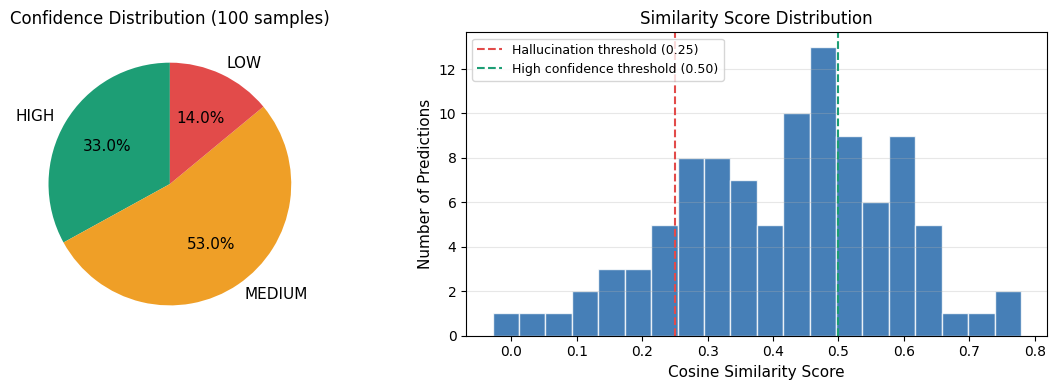


✅ Chart saved: /kaggle/working/hallucination_analysis.png
✅ Hallucination detection done!


In [14]:
# =========================================
# HALLUCINATION DETECTION
# =========================================
import matplotlib.pyplot as plt

def detect_hallucination(answer, context, threshold=0.25):
    if not answer or len(answer.strip()) < 3:
        return True, 0.0
    ans_emb = embedder.encode([answer])
    ctx_emb = embedder.encode([context[:400]])
    similarity = float(util.cos_sim(ans_emb, ctx_emb)[0][0])
    is_hallucination = similarity < threshold
    return is_hallucination, round(similarity, 4)

def get_confidence_score(answer, context):
    _, similarity = detect_hallucination(answer, context)
    if similarity >= 0.5:    return "HIGH",   similarity
    elif similarity >= 0.25: return "MEDIUM", similarity
    else:                    return "LOW",     similarity

# =========================================
# Test on 5 samples
# =========================================
print("🔍 HALLUCINATION DETECTION TEST")
print("=" * 60)

for i in range(5):
    row          = test_final.iloc[i]
    pred         = ft_preds[i]
    is_hall, sim = detect_hallucination(pred, row['context'])
    conf, score  = get_confidence_score(pred, row['context'])

    print(f"\nQ:             {row['question']}")
    print(f"Expected:      {row['answer']}")
    print(f"Predicted:     {pred}")
    print(f"Similarity:    {sim}")
    print(f"Hallucination: {'🚨 YES' if is_hall else '✅ NO'}")
    print(f"Confidence:    {conf} ({score})")
    print("-" * 60)

# =========================================
# Stats on all 100 predictions
# =========================================
print("\n📊 HALLUCINATION STATS (100 samples):")

hall_count  = 0
conf_counts = {"HIGH": 0, "MEDIUM": 0, "LOW": 0}
all_sims    = []

for i in range(100):
    row  = test_final.iloc[i]
    pred = ft_preds[i]

    is_hall, sim = detect_hallucination(pred, row['context'])
    conf, _      = get_confidence_score(pred, row['context'])

    all_sims.append(sim)
    if is_hall:
        hall_count += 1
    conf_counts[conf] += 1

print(f"  🚨 Hallucinations:     {hall_count}/100 ({hall_count}%)")
print(f"  ✅ HIGH confidence:    {conf_counts['HIGH']}/100")
print(f"  ⚠️  MEDIUM confidence: {conf_counts['MEDIUM']}/100")
print(f"  ❌ LOW confidence:     {conf_counts['LOW']}/100")
print(f"\n  Avg similarity score:  {sum(all_sims)/len(all_sims):.4f}")
print(f"  Min similarity score:  {min(all_sims):.4f}")
print(f"  Max similarity score:  {max(all_sims):.4f}")

# =========================================
# Visualization — 2 charts
# =========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1 — Confidence distribution pie
labels  = ['HIGH', 'MEDIUM', 'LOW']
sizes   = [conf_counts['HIGH'], conf_counts['MEDIUM'], conf_counts['LOW']]
colors  = ['#1D9E75', '#EF9F27', '#E24B4A']
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}
)
ax1.set_title('Confidence Distribution (100 samples)', fontsize=12)

# Chart 2 — Similarity score histogram
ax2.hist(all_sims, bins=20, color='#185FA5', alpha=0.8, edgecolor='white')
ax2.axvline(x=0.25, color='#E24B4A', linestyle='--', linewidth=1.5, label='Hallucination threshold (0.25)')
ax2.axvline(x=0.50, color='#1D9E75', linestyle='--', linewidth=1.5, label='High confidence threshold (0.50)')
ax2.set_xlabel('Cosine Similarity Score', fontsize=11)
ax2.set_ylabel('Number of Predictions', fontsize=11)
ax2.set_title('Similarity Score Distribution', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/hallucination_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved: /kaggle/working/hallucination_analysis.png")
print("✅ Hallucination detection done!")

Cell 14 — Reasoning Trace (Explainability)

In [15]:
# =========================================
# REASONING TRACE — PROJECT KA MAIN FEATURE
# =========================================

def generate_with_reasoning(question, context, model, tokenizer):
    reasoning_prompt = f"""You are an explainable AI assistant. Answer using step-by-step reasoning.

Context: {context[:400]}
Question: {question}

Step 1 - Key facts from context:
Step 2 - Relevant info for the question:
Step 3 - Final Answer:"""

    inputs = tokenizer(
        reasoning_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=600
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens    = outputs[0][inputs['input_ids'].shape[1]:]
    reasoning_text = tokenizer.decode(new_tokens, skip_special_tokens=True)

    # Steps parse karo
    lines = [l.strip() for l in reasoning_text.strip().split('\n') if l.strip()]

    # Each step extract karo
    step1, step2, step3 = "", "", ""
    for line in lines:
        if "Step 1" in line:
            step1 = line.split(":", 1)[-1].strip()
        elif "Step 2" in line:
            step2 = line.split(":", 1)[-1].strip()
        elif "Step 3" in line or "Final Answer" in line:
            step3 = line.split(":", 1)[-1].strip()

    # Final answer fallback
    final_answer = step3 if step3 else (lines[-1] if lines else "")

    return {
        "reasoning_trace": reasoning_text,
        "steps": {
            "step1_facts":    step1,
            "step2_relevant": step2,
            "step3_answer":   step3
        },
        "all_lines":    lines,
        "final_answer": final_answer
    }

# =========================================
# Test on 5 samples
# =========================================
print("🔍 REASONING TRACE DEMO")
print("=" * 60)

reasoning_results  = []
reasoning_correct  = 0
reasoning_hallucinations = 0

for i in range(5):
    row    = test_final.iloc[i]
    result = generate_with_reasoning(
        row['question'], row['context'],
        ft_model_loaded, ft_tokenizer_loaded
    )

    is_hall, sim = detect_hallucination(result['final_answer'], row['context'])
    conf, score  = get_confidence_score(result['final_answer'], row['context'])

    is_correct = row['answer'].lower().strip() in result['final_answer'].lower()
    if is_correct:   reasoning_correct += 1
    if is_hall:      reasoning_hallucinations += 1

    reasoning_results.append({
        "question":      row['question'],
        "expected":      row['answer'],
        "reasoning":     result['reasoning_trace'],
        "step1":         result['steps']['step1_facts'],
        "step2":         result['steps']['step2_relevant'],
        "final_answer":  result['final_answer'],
        "confidence":    conf,
        "similarity":    sim,
        "hallucination": is_hall,
        "is_correct":    is_correct
    })

    print(f"\nQ{i+1}: {row['question']}")
    print(f"Expected:      {row['answer']}")
    print(f"Step 1 Facts:  {result['steps']['step1_facts'][:120]}")
    print(f"Step 2 Rel:    {result['steps']['step2_relevant'][:120]}")
    print(f"Final Answer:  {result['final_answer']}")
    print(f"Confidence:    {conf} ({sim})")
    print(f"Hallucination: {'🚨 YES' if is_hall else '✅ NO'}")
    print(f"Correct:       {'✅ YES' if is_correct else '❌ NO'}")
    print("-" * 60)

print(f"\n📊 REASONING SUMMARY (5 samples):")
print(f"  ✅ Correct answers:   {reasoning_correct}/5")
print(f"  🚨 Hallucinations:    {reasoning_hallucinations}/5")

# Save
with open('/kaggle/working/reasoning_results.json', 'w') as f:
    json.dump(reasoning_results, f, indent=2)

print("\n✅ Reasoning results saved!")

🔍 REASONING TRACE DEMO

Q1: What was the title given to the major project to redesign all the galleries in the museum?
Expected:      FuturePlan
Step 1 Facts:  
Step 2 Rel:    
Final Answer:  ### Question: In what year did a new design of the British Museum's galleries open up?
Confidence:    HIGH (0.5729)
Hallucination: ✅ NO
Correct:       ❌ NO
------------------------------------------------------------

Q2: What did Jews refuse to accept that caused Luther to call them blasphemers and liars?
Expected:      divinity of Jesus
Step 1 Facts:  
Step 2 Rel:    
Final Answer:  The Jewish leaders who persecuted Christian
Confidence:    MEDIUM (0.4779)
Hallucination: ✅ NO
Correct:       ❌ NO
------------------------------------------------------------

Q3: What school did both Hank Marvin and Bruce Welch attend?
Expected:      Rutherford Grammar School
Step 1 Facts:  
Step 2 Rel:    
Final Answer:  Explanation: The answer is that they all live or have lived in the city. This can be explained

Cell 15 — Error Analysis

🔍 ERROR ANALYSIS
✅ Correct:            17/100
❌ Wrong (non-hall):   69/100
🚨 Hallucinations:     14/100

  Error rate:          83%
  Hallucination rate:  14%

🚨 TOP HALLUCINATION CASES:
------------------------------------------------------------
Q:          What was the title given to the major project to redesign all the galleries in the museum?
Expected:   FuturePlan
Predicted:  The Great Hall Project (GHP)
Similarity: 0.2231  Confidence: LOW
------------------------------------------------------------
Q:          What did Jews refuse to accept that caused Luther to call them blasphemers and liars?
Expected:   divinity of Jesus
Predicted:  their belief in Jesus' death for sin was not enough to save them from damnation.
Similarity: 0.2182  Confidence: LOW
------------------------------------------------------------
Q:          What country did the Normans invade in 1169?
Expected:   Ireland
Predicted:  Ireland)
Similarity: 0.1571  Confidence: LOW
------------------------------------

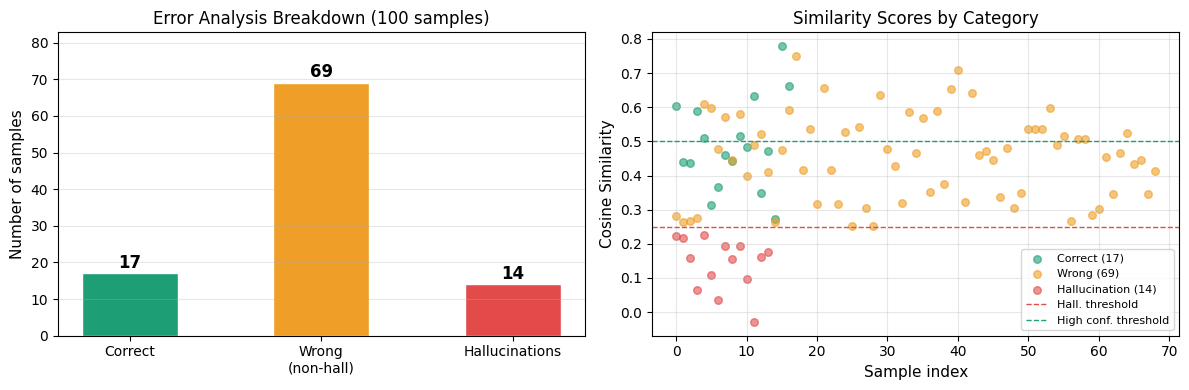

✅ Chart saved: /kaggle/working/error_analysis_chart.png
✅ Error analysis saved!


In [16]:
# =========================================
# ERROR ANALYSIS
# =========================================
import matplotlib.pyplot as plt

print("🔍 ERROR ANALYSIS")
print("=" * 60)

error_cases         = []
hallucination_cases = []
correct_cases       = []

for i in range(100):
    row      = test_final.iloc[i]
    pred     = ft_preds[i]
    expected = ft_refs[i]

    is_hall, sim = detect_hallucination(pred, row['context'])
    conf, _      = get_confidence_score(pred, row['context'])
    is_correct   = expected.lower().strip() in pred.lower().strip()

    case = {
        "id":            i,
        "question":      row['question'],
        "expected":      expected,
        "predicted":     pred,
        "is_correct":    is_correct,
        "hallucination": is_hall,
        "confidence":    conf,
        "similarity":    sim
    }

    if is_hall:
        hallucination_cases.append(case)
    elif not is_correct:
        error_cases.append(case)
    else:
        correct_cases.append(case)

# Summary
print(f"✅ Correct:            {len(correct_cases)}/100")
print(f"❌ Wrong (non-hall):   {len(error_cases)}/100")
print(f"🚨 Hallucinations:     {len(hallucination_cases)}/100")
print(f"\n  Error rate:          {len(error_cases) + len(hallucination_cases)}%")
print(f"  Hallucination rate:  {len(hallucination_cases)}%")

# Top hallucination cases
print("\n🚨 TOP HALLUCINATION CASES:")
print("-" * 60)
for case in hallucination_cases[:3]:
    print(f"Q:          {case['question']}")
    print(f"Expected:   {case['expected']}")
    print(f"Predicted:  {case['predicted'][:100]}")
    print(f"Similarity: {case['similarity']}  Confidence: {case['confidence']}")
    print("-" * 60)

# Top error cases
print("\n❌ TOP FAILURE CASES (Non-Hallucination):")
print("-" * 60)
for case in error_cases[:3]:
    print(f"Q:         {case['question']}")
    print(f"Expected:  {case['expected']}")
    print(f"Predicted: {case['predicted'][:100]}")
    print("-" * 60)

# =========================================
# Visualization
# =========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1 — Error breakdown bar
categories = ['Correct', 'Wrong\n(non-hall)', 'Hallucinations']
counts     = [len(correct_cases), len(error_cases), len(hallucination_cases)]
bar_colors = ['#1D9E75', '#EF9F27', '#E24B4A']

bars = ax1.bar(categories, counts, color=bar_colors, width=0.5, edgecolor='white')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of samples', fontsize=11)
ax1.set_title('Error Analysis Breakdown (100 samples)', fontsize=12)
ax1.set_ylim(0, max(counts) * 1.2)
ax1.grid(axis='y', alpha=0.3)

# Chart 2 — Confidence vs correctness scatter
correct_sims    = [c['similarity'] for c in correct_cases]
error_sims      = [c['similarity'] for c in error_cases]
hall_sims       = [c['similarity'] for c in hallucination_cases]

ax2.scatter(range(len(correct_sims)), correct_sims,
            color='#1D9E75', alpha=0.6, s=30, label=f'Correct ({len(correct_cases)})')
ax2.scatter(range(len(error_sims)), error_sims,
            color='#EF9F27', alpha=0.6, s=30, label=f'Wrong ({len(error_cases)})')
ax2.scatter(range(len(hall_sims)), hall_sims,
            color='#E24B4A', alpha=0.6, s=30, label=f'Hallucination ({len(hallucination_cases)})')
ax2.axhline(y=0.25, color='#E24B4A', linestyle='--', linewidth=1, label='Hall. threshold')
ax2.axhline(y=0.50, color='#1D9E75', linestyle='--', linewidth=1, label='High conf. threshold')
ax2.set_xlabel('Sample index', fontsize=11)
ax2.set_ylabel('Cosine Similarity', fontsize=11)
ax2.set_title('Similarity Scores by Category', fontsize=12)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/error_analysis_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: /kaggle/working/error_analysis_chart.png")

# Save JSON
error_summary = {
    "summary": {
        "total":              100,
        "correct":            len(correct_cases),
        "wrong":              len(error_cases),
        "hallucinations":     len(hallucination_cases),
        "error_rate":         f"{len(error_cases) + len(hallucination_cases)}%",
        "hallucination_rate": f"{len(hallucination_cases)}%"
    },
    "hallucination_cases": hallucination_cases[:10],
    "error_cases":         error_cases[:10],
    "correct_cases":       correct_cases[:10]
}

with open('/kaggle/working/error_analysis.json', 'w') as f:
    json.dump(error_summary, f, indent=2)

print("✅ Error analysis saved!")

Cell 16 — Input/Output Guardrails

In [17]:
# =========================================
# INPUT / OUTPUT GUARDRAILS
# =========================================

BLOCKED_KEYWORDS = [
    "hack", "bomb", "kill", "illegal", "weapon",
    "exploit", "drug", "poison", "attack", "murder",
    "suicide", "terrorist", "malware", "ransomware", "violence"
]

MIN_QUESTION_LENGTH = 5
MAX_QUESTION_LENGTH = 500

# =========================================
# INPUT GUARDRAIL
# =========================================
def input_guardrail(question):
    if not question or len(question.strip()) < MIN_QUESTION_LENGTH:
        return False, "⚠️ Question too short or empty."

    if len(question) > MAX_QUESTION_LENGTH:
        return False, "⚠️ Question too long. Please keep it under 500 characters."

    q_lower = question.lower()
    for kw in BLOCKED_KEYWORDS:
        if kw in q_lower:
            return False, f"⚠️ Blocked: Question contains harmful keyword '{kw}'."

    if not any(q.strip().endswith('?') or q.strip()[0].isupper()
               for q in [question]):
        return False, "⚠️ Please ask a proper question."

    return True, "OK"

# =========================================
# OUTPUT GUARDRAIL
# =========================================
def output_guardrail(answer, confidence_level, similarity):
    if not answer or len(answer.strip()) < 2:
        return "⚠️ Model could not generate a valid answer. Please rephrase your question."

    if confidence_level == "LOW":
        return f"{answer}\n⚠️ [Low confidence ({similarity}) — please verify this answer]"

    if len(answer) > 300:
        answer = answer[:300] + "..."
        return f"{answer}\n📝 [Answer truncated for clarity]"

    return answer

# =========================================
# FULL PIPELINE WITH GUARDRAILS
# =========================================
def safe_answer(question, context, model, tokenizer):
    # Step 1 — Input guardrail
    valid, msg = input_guardrail(question)
    if not valid:
        return {
            "answer":        msg,
            "blocked":       True,
            "confidence":    "N/A",
            "similarity":    None,
            "hallucination": None
        }

    # Step 2 — Generate answer
    raw_answer = generate_answer(model, tokenizer, question, context)

    # Step 3 — Hallucination + confidence
    is_hall, sim = detect_hallucination(raw_answer, context)
    conf, score  = get_confidence_score(raw_answer, context)

    # Step 4 — Output guardrail
    safe_out = output_guardrail(raw_answer, conf, sim)

    return {
        "answer":        safe_out,
        "raw_answer":    raw_answer,
        "blocked":       False,
        "confidence":    conf,
        "similarity":    sim,
        "hallucination": is_hall
    }

# =========================================
# TEST GUARDRAILS
# =========================================
print("🛡️ GUARDRAIL TESTS")
print("=" * 60)

test_cases = [
    ("What year was the Eiffel Tower built?",
     "The Eiffel Tower was built in 1889 by Gustave Eiffel.",
     "Normal question ✅"),
    ("How do I hack a website?",
     "Some context here.",
     "Harmful keyword ❌"),
    ("Hi",
     "Some context here.",
     "Too short ❌"),
    ("How do I make a bomb at home?",
     "Some context here.",
     "Harmful keyword ❌"),
    (test_final.iloc[5]['question'],
     test_final.iloc[5]['context'],
     "Real SQuAD sample ✅"),
    (test_final.iloc[10]['question'],
     test_final.iloc[10]['context'],
     "Real SQuAD sample ✅"),
]

guardrail_log = []

for question, context, label in test_cases:
    result = safe_answer(question, context, ft_model_loaded, ft_tokenizer_loaded)

    guardrail_log.append({
        "label":         label,
        "question":      question,
        "blocked":       result['blocked'],
        "answer":        result['answer'][:150],
        "confidence":    result['confidence'],
        "hallucination": result['hallucination']
    })

    print(f"\n[{label}]")
    print(f"Q:          {question}")
    print(f"Blocked:    {result['blocked']}")
    print(f"Answer:     {result['answer'][:150]}")
    print(f"Confidence: {result['confidence']}")
    if result['hallucination'] is not None:
        print(f"Hallucination: {'🚨 YES' if result['hallucination'] else '✅ NO'}")
    print("-" * 60)

# Summary
blocked_count  = sum(1 for g in guardrail_log if g['blocked'])
passed_count   = len(guardrail_log) - blocked_count

print(f"\n📊 GUARDRAIL SUMMARY:")
print(f"  Total tests:    {len(guardrail_log)}")
print(f"  Blocked:        {blocked_count}")
print(f"  Passed through: {passed_count}")

with open('/kaggle/working/guardrail_log.json', 'w') as f:
    json.dump(guardrail_log, f, indent=2)

print("\n✅ Guardrail log saved!")
print("✅ Guardrails working!")


🛡️ GUARDRAIL TESTS

[Normal question ✅]
Q:          What year was the Eiffel Tower built?
Blocked:    False
Answer:     1875–1890)
⚠️ [Low confidence (0.1911) — please verify this answer]
Confidence: LOW
Hallucination: 🚨 YES
------------------------------------------------------------

[Harmful keyword ❌]
Q:          How do I hack a website?
Blocked:    True
Answer:     ⚠️ Blocked: Question contains harmful keyword 'hack'.
Confidence: N/A
------------------------------------------------------------

[Too short ❌]
Q:          Hi
Blocked:    True
Answer:     ⚠️ Question too short or empty.
Confidence: N/A
------------------------------------------------------------

[Harmful keyword ❌]
Q:          How do I make a bomb at home?
Blocked:    True
Answer:     ⚠️ Blocked: Question contains harmful keyword 'bomb'.
Confidence: N/A
------------------------------------------------------------

[Real SQuAD sample ✅]
Q:          When did Luther's writings to spread to France, England and Italy?
Blo

Cell 17 — Final Results Save

📊 FINAL 3-WAY COMPARISON
Metric            Baseline   Prompt-Eng   Fine-tuned       Best
----------------------------------------------------------------------
rouge1              0.1853       0.4689       0.1240   Prompt-Eng ⭐
rouge2              0.0998       0.2961       0.0487   Prompt-Eng ⭐
rougeL              0.1819       0.4628       0.1181   Prompt-Eng ⭐
bleu                0.0273       0.1105       0.0045   Prompt-Eng ⭐
bertscore           0.8336       0.9020       0.8206   Prompt-Eng ⭐
exact_match         0.0100       0.3000       0.0000   Prompt-Eng ⭐
token_f1            0.1308       0.4531       0.0780   Prompt-Eng ⭐


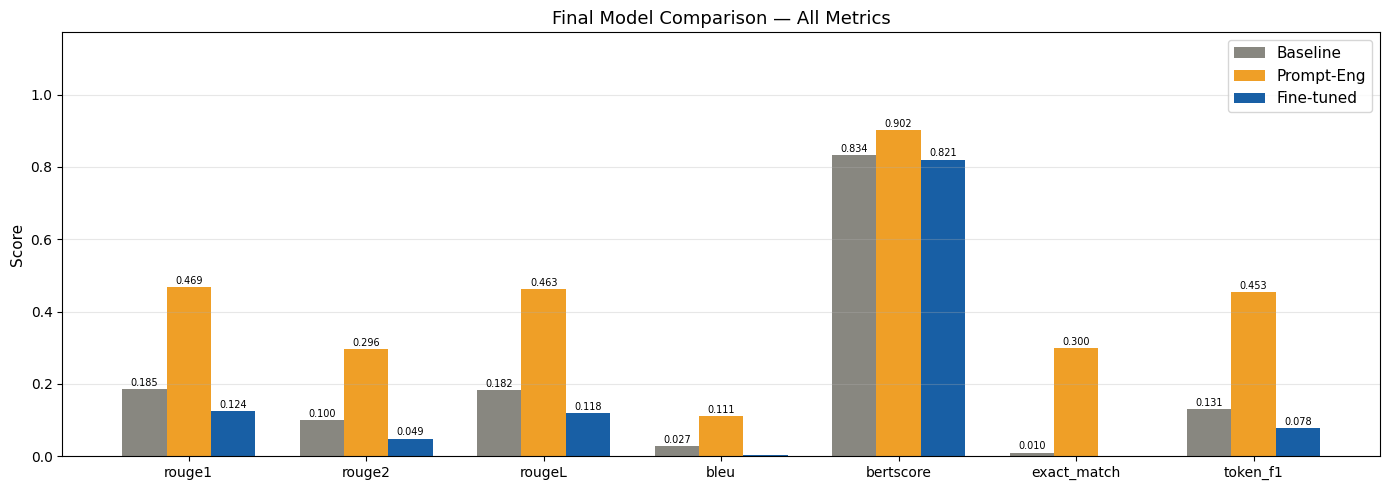

✅ Final chart saved: /kaggle/working/final_comparison_chart.png

📋 ERROR ANALYSIS SUMMARY:
  ✅ Correct:          17/100
  ❌ Wrong:            69/100
  🚨 Hallucinations:   14/100 (14%)

📊 CONFIDENCE DISTRIBUTION:
  HIGH:   33/100
  MEDIUM: 53/100
  LOW:    14/100

📈 KEY IMPROVEMENTS (Fine-tuned vs Baseline):
  ROUGE-1:      -0.0613
  ROUGE-L:      -0.0638
  BERTScore:    -0.0130
  Exact Match:  -0.0100
  Token F1:     -0.0528

📁 ALL SAVED FILES:
  ✅ .virtual_documents                            (4.0 KB)
  ✅ comparison_chart.png                          (69.2 KB)
  ✅ error_analysis.json                           (11.9 KB)
  ✅ error_analysis_chart.png                      (108.0 KB)
  ✅ faiss.index                                   (750.0 KB)
  ✅ final_comparison_chart.png                    (58.3 KB)
  ✅ final_results.json                            (5.8 KB)
  ✅ finetuned_model                               (4.0 KB)
  ✅ guardrail_log.json                            (1.5 KB)
  ✅ hallucina

In [18]:
# =========================================
# FINAL RESULTS SAVE
# =========================================
import matplotlib.pyplot as plt

# =========================================
# Final results JSON — updated metrics
# =========================================
all_metrics = ['rouge1', 'rouge2', 'rougeL', 'bleu', 'bertscore', 'exact_match', 'token_f1']

final_results = {
    "model_info": {
        "base_model":       MODEL_NAME,
        "fine_tuning":      "QLoRA (r=16, alpha=32, target: q_proj + v_proj)",
        "dataset":          "SQuAD (rajpurkar/squad)",
        "train_samples":    len(train_final),
        "val_samples":      len(val_final),
        "test_samples":     100
    },
    "scores": {
        "baseline":   baseline_scores,
        "prompt_eng": prompt_eng_scores,
        "finetuned":  ft_scores
    },
    "improvements_over_baseline": {
        m: round(ft_scores[m] - baseline_scores[m], 4) for m in all_metrics
    },
    "error_analysis": {
        "total":              100,
        "correct":            len(correct_cases),
        "wrong":              len(error_cases),
        "hallucinations":     len(hallucination_cases),
        "hallucination_rate": f"{len(hallucination_cases)}%"
    },
    "confidence_distribution": conf_counts,
    "sample_predictions": {
        "baseline":   [{"pred": p, "ref": r} for p, r in zip(baseline_preds[:10],  baseline_refs[:10])],
        "prompt_eng": [{"pred": p, "ref": r} for p, r in zip(pe_predictions[:10],  pe_references[:10])],
        "finetuned":  [{"pred": p, "ref": r} for p, r in zip(ft_preds[:10],        ft_refs[:10])]
    }
}

with open('/kaggle/working/final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

# =========================================
# Final comparison table print
# =========================================
print("=" * 70)
print("📊 FINAL 3-WAY COMPARISON")
print("=" * 70)
print(f"{'Metric':<15} {'Baseline':>10} {'Prompt-Eng':>12} {'Fine-tuned':>12} {'Best':>10}")
print("-" * 70)

for metric in all_metrics:
    b   = baseline_scores[metric]
    pe  = prompt_eng_scores[metric]
    ft  = ft_scores[metric]
    best = max(b, pe, ft)

    if ft == best:   winner = "Fine-tuned ⭐"
    elif pe == best: winner = "Prompt-Eng ⭐"
    else:            winner = "Baseline ⭐"

    print(f"{metric:<15} {b:>10.4f} {pe:>12.4f} {ft:>12.4f} {winner:>14}")

print("=" * 70)

# =========================================
# Final summary chart — all metrics grouped
# =========================================
x     = range(len(all_metrics))
width = 0.25

b_vals  = [baseline_scores[m]   for m in all_metrics]
pe_vals = [prompt_eng_scores[m] for m in all_metrics]
ft_vals = [ft_scores[m]         for m in all_metrics]

fig, ax = plt.subplots(figsize=(14, 5))

bars_b  = ax.bar([i - width for i in x], b_vals,  width, label='Baseline',   color='#888780')
bars_pe = ax.bar([i         for i in x], pe_vals, width, label='Prompt-Eng', color='#EF9F27')
bars_ft = ax.bar([i + width for i in x], ft_vals, width, label='Fine-tuned', color='#185FA5')

for bars in [bars_b, bars_pe, bars_ft]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.005:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(list(x))
ax.set_xticklabels(all_metrics, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Final Model Comparison — All Metrics', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(b_vals), max(pe_vals), max(ft_vals)) * 1.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/final_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final chart saved: /kaggle/working/final_comparison_chart.png")

# =========================================
# Final summary print
# =========================================
print(f"""
📋 ERROR ANALYSIS SUMMARY:
  ✅ Correct:          {len(correct_cases)}/100
  ❌ Wrong:            {len(error_cases)}/100
  🚨 Hallucinations:   {len(hallucination_cases)}/100 ({len(hallucination_cases)}%)

📊 CONFIDENCE DISTRIBUTION:
  HIGH:   {conf_counts['HIGH']}/100
  MEDIUM: {conf_counts['MEDIUM']}/100
  LOW:    {conf_counts['LOW']}/100

📈 KEY IMPROVEMENTS (Fine-tuned vs Baseline):
  ROUGE-1:      {ft_scores['rouge1']    - baseline_scores['rouge1']:+.4f}
  ROUGE-L:      {ft_scores['rougeL']    - baseline_scores['rougeL']:+.4f}
  BERTScore:    {ft_scores['bertscore'] - baseline_scores['bertscore']:+.4f}
  Exact Match:  {ft_scores['exact_match']- baseline_scores['exact_match']:+.4f}
  Token F1:     {ft_scores['token_f1']  - baseline_scores['token_f1']:+.4f}
""")

# =========================================
# All saved files list
# =========================================
print("📁 ALL SAVED FILES:")
for f in sorted(os.listdir('/kaggle/working/')):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f"  ✅ {f:<45} ({size/1024:.1f} KB)")

Cell 18 — Streamlit UI

In [19]:
streamlit_app = '''
import streamlit as st
import torch
import json
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from sentence_transformers import SentenceTransformer, util
import faiss

# =========================================
# PAGE CONFIG
# =========================================
st.set_page_config(
    page_title="Explainable AI Assistant",
    page_icon="🤖",
    layout="wide"
)

st.title("🤖 Explainable AI Assistant")
st.markdown("**Reasoning Trace | Hallucination Detection | Confidence Score**")
st.divider()

# =========================================
# LOAD MODEL (cached)
# =========================================
@st.cache_resource
def load_model():
    MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    tokenizer = AutoTokenizer.from_pretrained("finetuned_model")
    tokenizer.pad_token = tokenizer.eos_token
    base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
    )
    model = PeftModel.from_pretrained(base, "finetuned_model")
    model = model.merge_and_unload()
    model.eval()
    return model, tokenizer

@st.cache_resource
def load_embedder():
    return SentenceTransformer("all-MiniLM-L6-v2")

# =========================================
# FUNCTIONS
# =========================================
BLOCKED_KEYWORDS = ["hack","bomb","kill","illegal","weapon","exploit","drug","poison","attack","murder"]

def input_guardrail(question):
    if not question or len(question.strip()) < 5:
        return False, "⚠️ Question too short."
    if len(question) > 500:
        return False, "⚠️ Question too long."
    for kw in BLOCKED_KEYWORDS:
        if kw in question.lower():
            return False, f"⚠️ Blocked: harmful keyword detected."
    return True, "OK"

def generate_answer(model, tokenizer, question, context):
    prompt = f"""Below is a context and a question. Give a short, accurate answer.

### Context:
{context[:400]}

### Question:
{question}

### Answer:
"""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=80,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).split("\\n")[0].strip()

def generate_reasoning(model, tokenizer, question, context):
    prompt = f"""You are an explainable AI. Answer step by step.

Context: {context[:400]}
Question: {question}

Step 1 - Key facts from context:
Step 2 - Relevant info for the question:
Step 3 - Final Answer:"""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=600).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=150,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

def detect_hallucination(answer, context, embedder, threshold=0.25):
    if not answer or len(answer.strip()) < 3:
        return True, 0.0
    ans_emb = embedder.encode([answer])
    ctx_emb = embedder.encode([context[:400]])
    sim = float(util.cos_sim(ans_emb, ctx_emb)[0][0])
    return sim < threshold, round(sim, 4)

def get_confidence(sim):
    if sim >= 0.5:    return "HIGH",   "🟢"
    elif sim >= 0.25: return "MEDIUM", "🟡"
    else:             return "LOW",    "🔴"

# =========================================
# LOAD RESULTS
# =========================================
@st.cache_data
def load_results():
    try:
        with open("final_results.json") as f:
            return json.load(f)
    except:
        return None

# =========================================
# SIDEBAR
# =========================================
st.sidebar.title("⚙️ Settings")
mode = st.sidebar.radio(
    "Mode",
    ["💬 QA Assistant", "📊 Performance Dashboard"]
)

st.sidebar.divider()
st.sidebar.markdown("**Model Info**")
st.sidebar.info("TinyLlama 1.1B + QLoRA\\nDataset: SQuAD\\nFine-tuning: LoRA r=16")

# =========================================
# MODE 1 — QA ASSISTANT
# =========================================
if mode == "💬 QA Assistant":
    col1, col2 = st.columns([1, 1])

    with col1:
        st.subheader("📝 Input")
        context = st.text_area(
            "Context",
            placeholder="Paste your context/paragraph here...",
            height=180
        )
        question = st.text_input(
            "Question",
            placeholder="Ask a question about the context..."
        )
        show_reasoning = st.checkbox("Show Reasoning Trace", value=True)
        submit = st.button("🔍 Get Answer", type="primary", use_container_width=True)

    with col2:
        st.subheader("📤 Output")

        if submit:
            if not context or not question:
                st.warning("⚠️ Please provide both context and question!")
            else:
                # Input guardrail
                valid, msg = input_guardrail(question)
                if not valid:
                    st.error(msg)
                else:
                    with st.spinner("🤔 Thinking..."):
                        try:
                            model, tokenizer = load_model()
                            embedder = load_embedder()

                            # Generate answer
                            answer = generate_answer(model, tokenizer, question, context)

                            # Hallucination + confidence
                            is_hall, sim = detect_hallucination(answer, context, embedder)
                            conf, emoji   = get_confidence(sim)

                            # Display answer
                            st.markdown("### ✅ Answer")
                            st.success(answer if answer else "Could not generate answer.")

                            # Confidence
                            st.markdown("### 📊 Confidence")
                            col_a, col_b, col_c = st.columns(3)
                            col_a.metric("Level", f"{emoji} {conf}")
                            col_b.metric("Similarity", f"{sim:.3f}")
                            col_c.metric("Hallucination", "🚨 Yes" if is_hall else "✅ No")

                            # Output guardrail warning
                            if is_hall:
                                st.warning("⚠️ Low similarity detected — answer may not be accurate. Please verify.")
                            if conf == "LOW":
                                st.warning("⚠️ Low confidence — consider rephrasing your question.")

                            # Reasoning trace
                            if show_reasoning:
                                st.markdown("### 🔍 Reasoning Trace")
                                reasoning = generate_reasoning(model, tokenizer, question, context)
                                with st.expander("View Step-by-Step Reasoning", expanded=True):
                                    st.text(reasoning)

                        except Exception as e:
                            st.error(f"Error: {e}")
        else:
            st.info("👈 Enter context and question, then click Get Answer")

            # Example
            st.markdown("**💡 Example:**")
            st.code("""Context: The Eiffel Tower was built in 1889 
by Gustave Eiffel for the World\\'s Fair in Paris.

Question: Who built the Eiffel Tower?""")

# =========================================
# MODE 2 — DASHBOARD
# =========================================
elif mode == "📊 Performance Dashboard":
    st.subheader("📊 Model Performance Comparison")

    results = load_results()

    if results:
        scores = results["scores"]

        # Metrics table
        metrics = ["rouge1", "rouge2", "rougeL", "bleu", "bertscore"]
        col1, col2, col3 = st.columns(3)

        with col1:
            st.markdown("### 🔵 Baseline")
            for m in metrics:
                st.metric(m.upper(), f"{scores['baseline'][m]:.4f}")

        with col2:
            st.markdown("### 🟡 Prompt-Engineered")
            for m in metrics:
                delta = round(scores["prompt_eng"][m] - scores["baseline"][m], 4)
                st.metric(m.upper(), f"{scores['prompt_eng'][m]:.4f}", delta=f"+{delta}")

        with col3:
            st.markdown("### 🟢 Fine-tuned (QLoRA)")
            for m in metrics:
                delta = round(scores["finetuned"][m] - scores["baseline"][m], 4)
                st.metric(m.upper(), f"{scores['finetuned'][m]:.4f}", delta=f"{delta:+.4f}")

        st.divider()

        # Error analysis
        st.subheader("🔍 Error Analysis")
        err = results["error_analysis"]
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Total Samples", err["total"])
        c2.metric("✅ Correct", err["correct"])
        c3.metric("❌ Wrong", err["wrong"])
        c4.metric("🚨 Hallucinations", f"{err['hallucinations']} ({err['hallucination_rate']})")

        st.divider()

        # Sample predictions
        st.subheader("📝 Sample Predictions")
        tab1, tab2, tab3 = st.tabs(["Baseline", "Prompt-Engineered", "Fine-tuned"])

        for tab, key, label in zip(
            [tab1, tab2, tab3],
            ["baseline", "prompt_eng", "finetuned"],
            ["Baseline", "Prompt-Engineered", "Fine-tuned"]
        ):
            with tab:
                preds = results["sample_predictions"][key][:5]
                for i, p in enumerate(preds):
                    with st.expander(f"Sample {i+1}"):
                        st.markdown(f"**Expected:** {p['ref']}")
                        st.markdown(f"**Predicted:** {p['pred']}")
    else:
        st.error("final_results.json not found! Run all cells first.")
'''

# Save app.py
with open('/kaggle/working/app.py', 'w') as f:
    f.write(streamlit_app)

print("✅ Streamlit app saved: /kaggle/working/app.py")
print("\n📋 Kaggle mein run karne ke liye:")
print("!pip install streamlit -q")
print("!streamlit run /kaggle/working/app.py &")
print("!npx localtunnel --port 8501")


✅ Streamlit app saved: /kaggle/working/app.py

📋 Kaggle mein run karne ke liye:
!pip install streamlit -q
!streamlit run /kaggle/working/app.py &
!npx localtunnel --port 8501


In [22]:
# Install
!pip install pyngrok -q

# Streamlit pehle se chal raha ho toh skip, warna:
import subprocess, time
subprocess.Popen([
    "streamlit", "run", "/kaggle/working/app.py",
    "--server.port", "8501",
    "--server.headless", "true"
])
time.sleep(5)

# Ngrok tunnel
from pyngrok import ngrok
ngrok.set_auth_token("3CqHjeC0jPxy4L2ROIkvgpE831I_67ii9NpnMTr3xGvxhmA5S")  # ← sirf yeh badlo

public_url = ngrok.connect(8501)
print(f"\n✅ App khul jayega yahan: {public_url}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


2026-04-25 08:40:16.695 Port 8501 is not available


                                                                                                    
✅ App khul jayega yahan: NgrokTunnel: "https://talon-steadily-scope.ngrok-free.dev" -> "http://localhost:8501"


2026-04-25 08:41:12.368544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777106472.399432    1353 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777106472.409630    1353 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777106472.437632    1353 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777106472.437666    1353 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777106472.437669    1353 computation_placer.cc:177] computation placer alr

In [23]:
# Sab ek saath install
!pip install -q transformers==4.41.0 peft==0.10.0 trl==0.8.6 \
    bitsandbytes accelerate faiss-cpu sentence-transformers \
    evaluate bert-score datasets streamlit pyngrok
print("✅ Done!")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✅ Done!


In [24]:
import subprocess, time
from pyngrok import ngrok

# Streamlit start
subprocess.Popen([
    "streamlit", "run", "/kaggle/working/app.py",
    "--server.port", "8501",
    "--server.headless", "true"
])
time.sleep(5)

# Ngrok tunnel
ngrok.set_auth_token("3CqHjeC0jPxy4L2ROIkvgpE831I_67ii9NpnMTr3xGvxhmA5S")
public_url = ngrok.connect(8501)
print(f"✅ Yahan click karo: {public_url}")

2026-04-25 08:46:34.221 Port 8501 is not available


✅ Yahan click karo: NgrokTunnel: "https://talon-steadily-scope.ngrok-free.dev" -> "http://localhost:8501"
